CNN
VGG, MobileNet, Resnet, EfficientNet, DenseNet 

In [3]:
import tensorflow as tf

net = tf.keras.applications.MobileNetV2(weights='imagenet')
print(f'MobileNetV2 로드 완료 | 파라미터: {net.count_params():,}개 | 층 수: {len(net.layers)}개')

MobileNetV2 로드 완료 | 파라미터: 3,538,984개 | 층 수: 156개


### 저작권 없는 이미지
pixabay, unsplash, pexels

In [5]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

#경고문 패치
import warnings

warnings.filterwarnings('ignore')

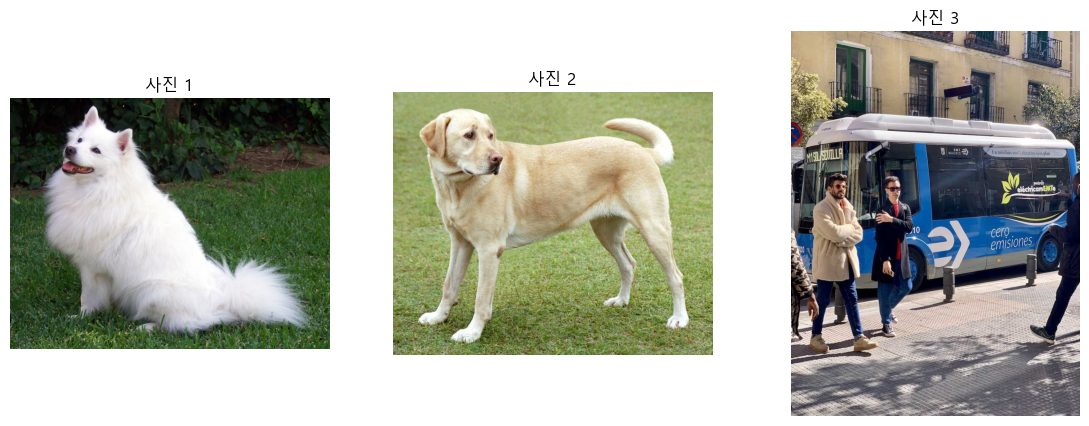

In [6]:
import urllib.request
import matplotlib.pyplot as plt

urllib.request.urlretrieve('https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg', 'dog.jpg')
urllib.request.urlretrieve('https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg', 'lab.jpg')
urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', 'bus.jpg')

img1 = plt.imread('dog.jpg') / 255.0 # 정규
img2 = plt.imread('lab.jpg') / 255.0
img3 = plt.imread('bus.jpg') / 255.0

plt.figure(figsize=(14, 5))
plt.subplot(1,3,1); plt.imshow(img1); plt.title('사진 1'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(img2); plt.title('사진 2'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(img3); plt.title('사진 3'); plt.axis('off')
plt.show()

In [7]:
import pandas as pd
import numpy as np

size = (224, 224)
batch = np.stack([tf.image.resize(img1, size),
                 tf.image.resize(img2, size),
                 tf.image.resize(img3, size)]) * 255.0

In [11]:
img_batch = tf.keras.applications.mobilenet_v2.preprocess_input(batch)
conf = net.predict(batch, verbose = 0)
result = tf.keras.applications.mobilenet_v2.decode_predictions(conf, top = 3)

print('=== 사진 1 ==='); print(pd.DataFrame(result[0], columns=['ID','예측(영문)','confidence']).round(3))
print('=== 사진 2 ==='); print(pd.DataFrame(result[1], columns=['ID','예측(영문)','confidence']).round(3))
print('=== 사진 3 ==='); print(pd.DataFrame(result[2], columns=['ID','예측(영문)','confidence']).round(3))

=== 사진 1 ===
          ID         예측(영문)  confidence
0  n04286575      spotlight       0.316
1  n03196217  digital_clock       0.033
2  n03729826     matchstick       0.032
=== 사진 2 ===
          ID         예측(영문)  confidence
0  n04286575      spotlight       0.316
1  n03196217  digital_clock       0.033
2  n03729826     matchstick       0.032
=== 사진 3 ===
          ID         예측(영문)  confidence
0  n04286575      spotlight       0.316
1  n03196217  digital_clock       0.033
2  n03729826     matchstick       0.032


In [12]:
#conf = net.predict(batch, verbose = 0)
img_samoyed = plt.imread('./data/samoyed.jpg')

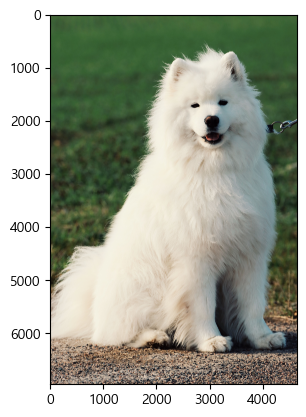

In [13]:
plt.imshow(img_samoyed)

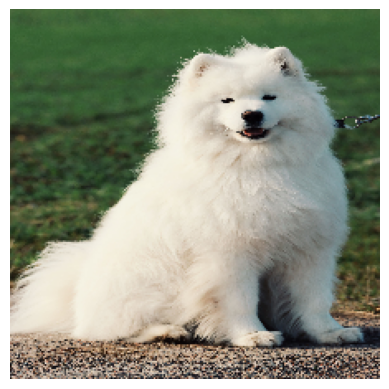

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
객체 판별 결과
Samoyed : 97.09%
chow : 0.66%
Pomeranian : 0.29%
keeshond : 0.12%
Great_Pyrenees : 0.06%


In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. MobileNetV2 모델 불러오기
model = tf.keras.applications.MobileNetV2(weights="imagenet")

# 2. 이미지 불러오기
img = tf.keras.utils.load_img("./data/samoyed.jpg", target_size=(224, 224))

# 3. 이미지 화면에 출력
plt.imshow(img)
plt.axis("off")
plt.show()

# 4. 이미지를 숫자 배열로 변환
img_array = tf.keras.utils.img_to_array(img)

# 5. 모델에 넣을 수 있도록 차원 추가
img_array = np.expand_dims(img_array, axis=0)

# 6. MobileNetV2용 전처리
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# 7. 예측하기
pred = model.predict(img_array)

# 8. 예측 결과 해석하기
result = tf.keras.applications.mobilenet_v2.decode_predictions(pred, top=5)

# 9. 결과 출력
print("객체 판별 결과")
print("==============================")

for name_id, name, score in result[0]:
    print(f"{name} : {score * 100:.2f}%")